# The Phantom Consensus: Exploring Fan Perspectives on the Star Wars Franchise

## Project Introduction

In 2014, prior to the release of the long-awaited seventh Star Wars episode [The Force Awakens](https://en.wikipedia.org/wiki/Star_Wars:_The_Force_Awakens), the team at [FiveThirtyEight](https://data.fivethirtyeight.com) grew interested in exploring the views and opinions of Star Wars fans - particularly which of the first six episodes were considered the best (and which characters were considered the worst).

In pursuit of data to answer their questions, they turned to the online surveying tool [SurveyMonkey](https://www.surveymonkey.com) to collect data from American volunteers related to the Star Wars franchise. The original survey data is publically available on [GitHub](https://github.com/fivethirtyeight/data/tree/master/star-wars-survey) and the corresponding article the team published can be found [here](https://fivethirtyeight.com/features/americas-favorite-star-wars-movies-and-least-favorite-characters).

## Aim

This work aims to clean and analyse the original dataset to draw conclusions about the general views of Star Wars viewers in America. The data gathered from the survey acts as a sample to describe the population of Star Wars viewers in America as a whole.

### Importing Libraries and Reading the Data

In [1]:
import numpy as np
import pandas as pd

pd.options.display.max_columns = 40

import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use('fivethirtyeight')

In [2]:
star_wars = pd.read_csv('StarWars_survey_responses.csv', encoding='ISO-8859-1')

star_wars.head()

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,"Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.",Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?æ,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Han Solo,Luke Skywalker,Princess Leia Organa,Anakin Skywalker,Obi Wan Kenobi,Emperor Palpatine,Darth Vader,Lando Calrissian,Boba Fett,C-3P0,R2 D2,Jar Jar Binks,Padme Amidala,Yoda,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,2,1,4,5,6,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,2,3,4,5,6,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,6,1,2,4,3,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


In [3]:
star_wars.drop(star_wars.head(1).index, inplace=True) # first row is redundant header info, dropped

In [4]:
star_wars.columns

Index(['RespondentID',
       'Have you seen any of the 6 films in the Star Wars franchise?',
       'Do you consider yourself to be a fan of the Star Wars film franchise?',
       'Which of the following Star Wars films have you seen? Please select all that apply.',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14',
       'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Which character shot first?',
       'Are you familiar with the Expan

Column names are verbose and unclear in some cases.

#### Renaming Columns

In [5]:
columns = {
    "RespondentID": "id",
    "Have you seen any of the 6 films in the Star Wars franchise?": "seen_any",
    "Do you consider yourself to be a fan of the Star Wars film franchise?": "fan",
    "Which of the following Star Wars films have you seen? Please select all that apply.": "seen_ep_1",
    "Unnamed: 4": "seen_ep_2",
    "Unnamed: 5": "seen_ep_3",
    "Unnamed: 6": "seen_ep_4",
    "Unnamed: 7": "seen_ep_5",
    "Unnamed: 8": "seen_ep_6",
    "Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.": "rank_ep_1",
    "Unnamed: 10": "rank_ep_2",
    "Unnamed: 11": "rank_ep_3", 
    "Unnamed: 12": "rank_ep_4",
    "Unnamed: 13": "rank_ep_5",
    "Unnamed: 14": "rank_ep_6",
    "Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.": "fav_hansolo",
    "Unnamed: 16": "fav_luke",
    "Unnamed: 17": "fav_leia",
    "Unnamed: 18": "fav_anakin",
    "Unnamed: 19": "fav_obiwan",
    "Unnamed: 20": "fav_palpatine",
    "Unnamed: 21": "fav_darthvader",
    "Unnamed: 22": "fav_lando",
    "Unnamed: 23": "fav_bobafett",
    "Unnamed: 24": "fav_c3po",
    "Unnamed: 25": "fav_r2d2",
    "Unnamed: 26": "fav_jarjar",
    "Unnamed: 27": "fav_padme",
    "Unnamed: 28": "fav_yoda",
    "Which character shot first?": "shot_first",
    "Are you familiar with the Expanded Universe?": "familiar_ex_uni",
    "Do you consider yourself to be a fan of the Expanded Universe?æ": "fan_ex_uni",
    "Do you consider yourself to be a fan of the Star Trek franchise?": "fan_star_trek",
    "Gender":"gender",
    "Age":"age",
    "Household Income":"income",
    "Education":"education",
    "Location (Census Region)":"location"
    }

star_wars = star_wars.rename(columns=columns)

star_wars.head()

,id,seen_any,fan,seen_ep_1,seen_ep_2,seen_ep_3,seen_ep_4,seen_ep_5,seen_ep_6,rank_ep_1,rank_ep_2,rank_ep_3,rank_ep_4,rank_ep_5,rank_ep_6,fav_hansolo,fav_luke,fav_leia,fav_anakin,fav_obiwan,fav_palpatine,fav_darthvader,fav_lando,fav_bobafett,fav_c3po,fav_r2d2,fav_jarjar,fav_padme,fav_yoda,shot_first,familiar_ex_uni,fan_ex_uni,fan_star_trek,gender,age,income,education,location
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,2,1,4,5,6,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,2,3,4,5,6,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,6,1,2,4,3,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3.292731e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,4,6,2,1,3,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


In [6]:
star_wars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 1 to 1186
Data columns (total 38 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1186 non-null   float64
 1   seen_any         1186 non-null   object 
 2   fan              836 non-null    object 
 3   seen_ep_1        673 non-null    object 
 4   seen_ep_2        571 non-null    object 
 5   seen_ep_3        550 non-null    object 
 6   seen_ep_4        607 non-null    object 
 7   seen_ep_5        758 non-null    object 
 8   seen_ep_6        738 non-null    object 
 9   rank_ep_1        835 non-null    object 
 10  rank_ep_2        836 non-null    object 
 11  rank_ep_3        835 non-null    object 
 12  rank_ep_4        836 non-null    object 
 13  rank_ep_5        836 non-null    object 
 14  rank_ep_6        836 non-null    object 
 15  fav_hansolo      829 non-null    object 
 16  fav_luke         831 non-null    object 
 17  fav_leia      

Some fields can be cleaned. It makes sense for Yes/No questions to be represented as a Boolean type (True/False), with missing data represented by NaN (not a number).

#### Converting `seen_any`, `fan` and "`seen_ep_1 ...`" Fields to Bool Type

In [7]:
mapping = {
    "Yes": True,
    "No": False,
    np.nan: np.nan
    }

star_wars["seen_any"] = star_wars["seen_any"].map(mapping)

star_wars["fan"] = star_wars["fan"].map(mapping)

In [8]:
star_wars["seen_any"].value_counts(dropna=False)

seen_any
True     936
False    250
Name: count, dtype: int64

In [9]:
star_wars["fan"].value_counts(dropna=False)

fan
True     552
NaN      350
False    284
Name: count, dtype: int64

In [10]:
star_wars["seen_ep_1"].value_counts(dropna=False)

seen_ep_1
Star Wars: Episode I  The Phantom Menace    673
NaN                                         513
Name: count, dtype: int64

In [11]:
mapping = {
  "Star Wars: Episode I  The Phantom Menace": True,
  "Star Wars: Episode II  Attack of the Clones": True,
  "Star Wars: Episode III  Revenge of the Sith": True,
  "Star Wars: Episode IV  A New Hope": True,
  "Star Wars: Episode V The Empire Strikes Back": True, 
  "Star Wars: Episode VI Return of the Jedi": True,
  True: True,
  np.nan: False
  }

for col in star_wars.columns[3:9]:
  star_wars[col] = star_wars[col].map(mapping)

In [12]:
star_wars["seen_ep_1"].value_counts(dropna=False)

seen_ep_1
True     673
False    513
Name: count, dtype: int64

#### Casting Rank Columns to Float Type

In [13]:
star_wars[star_wars.columns[9:15]] = star_wars[star_wars.columns[9:15]].astype(float)

In [14]:
star_wars.head()

,id,seen_any,fan,seen_ep_1,seen_ep_2,seen_ep_3,seen_ep_4,seen_ep_5,seen_ep_6,rank_ep_1,rank_ep_2,rank_ep_3,rank_ep_4,rank_ep_5,rank_ep_6,fav_hansolo,fav_luke,fav_leia,fav_anakin,fav_obiwan,fav_palpatine,fav_darthvader,fav_lando,fav_bobafett,fav_c3po,fav_r2d2,fav_jarjar,fav_padme,fav_yoda,shot_first,familiar_ex_uni,fan_ex_uni,fan_star_trek,gender,age,income,education,location
1,3.292880e+09,True,True,True,True,True,True,True,True,3.0,2.0,1.0,4.0,5.0,6.0,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,False,NaN,False,False,False,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,True,False,True,True,True,False,False,False,1.0,2.0,3.0,4.0,5.0,6.0,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,True,True,True,True,True,True,True,True,5.0,6.0,1.0,2.0,4.0,3.0,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3.292731e+09,True,True,True,True,True,True,True,True,5.0,4.0,6.0,2.0,1.0,3.0,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central


In [15]:
star_wars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 1 to 1186
Data columns (total 38 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1186 non-null   float64
 1   seen_any         1186 non-null   object 
 2   fan              836 non-null    object 
 3   seen_ep_1        1186 non-null   bool   
 4   seen_ep_2        1186 non-null   bool   
 5   seen_ep_3        1186 non-null   bool   
 6   seen_ep_4        1186 non-null   bool   
 7   seen_ep_5        1186 non-null   bool   
 8   seen_ep_6        1186 non-null   bool   
 9   rank_ep_1        835 non-null    float64
 10  rank_ep_2        836 non-null    float64
 11  rank_ep_3        835 non-null    float64
 12  rank_ep_4        836 non-null    float64
 13  rank_ep_5        836 non-null    float64
 14  rank_ep_6        836 non-null    float64
 15  fav_hansolo      829 non-null    object 
 16  fav_luke         831 non-null    object 
 17  fav_leia      

### Handling Character Preference Fields

To perform a sentiment analysis on the characters, it would be wise to reduce the granularity for each of the `fav_<char>` columns:

* Favorable responses are mapped to "Liked"

* Unfavorable responses mapped to "Disliked"

* Indifferent responses to "Neutral" 

* Unfamiliar responses to "Unfamiliar"

In [16]:
star_wars["fav_hansolo"].value_counts(dropna=False)

fav_hansolo
Very favorably                                 610
NaN                                            357
Somewhat favorably                             151
Neither favorably nor unfavorably (neutral)     44
Unfamiliar (N/A)                                15
Somewhat unfavorably                             8
Very unfavorably                                 1
Name: count, dtype: int64

In [17]:
mapping = {
    "Very favorably": "Liked",
    "Somewhat favorably": "Liked",
    "Neither favorably nor unfavorably (neutral)": "Neutral",
    "Unfamiliar (N/A)": "Unfamiliar",
    "Somewhat unfavorably": "Disliked",
    "Very unfavorably": "Disliked"
}
  
cols = list(star_wars.columns[15:29])

for col in cols:
  
  star_wars[col] = star_wars[col].map(mapping)
  
ids = star_wars[["id"]]

character_preferences = star_wars.iloc[:, 15:29]

character_preferences = pd.concat([ids, character_preferences], axis=1)

character_preferences.head()

,id,fav_hansolo,fav_luke,fav_leia,fav_anakin,fav_obiwan,fav_palpatine,fav_darthvader,fav_lando,fav_bobafett,fav_c3po,fav_r2d2,fav_jarjar,fav_padme,fav_yoda
1,3.292880e+09,Liked,Liked,Liked,Liked,Liked,Liked,Liked,Unfamiliar,Unfamiliar,Liked,Liked,Liked,Liked,Liked
2,3.292880e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.292765e+09,Liked,Liked,Liked,Liked,Liked,Unfamiliar,Unfamiliar,Unfamiliar,Unfamiliar,Unfamiliar,Unfamiliar,Unfamiliar,Unfamiliar,Unfamiliar
4,3.292763e+09,Liked,Liked,Liked,Liked,Liked,Liked,Liked,Liked,Disliked,Liked,Liked,Liked,Liked,Liked
5,3.292731e+09,Liked,Liked,Liked,Disliked,Liked,Disliked,Liked,Neutral,Liked,Liked,Liked,Disliked,Liked,Liked


---

# Analysis

## Best-Rated Movie

To gain an idea of the fan-favorite movie from the original six episodes, the mean ranking for each movie is calculated.

In [18]:
mean_movie_ranking = pd.DataFrame(star_wars.iloc[:, 9:15].mean(), columns=["mean_rank"])

mean_movie_ranking

,mean_rank
rank_ep_1,3.732934
rank_ep_2,4.087321
rank_ep_3,4.341317
rank_ep_4,3.272727
rank_ep_5,2.513158
rank_ep_6,3.047847


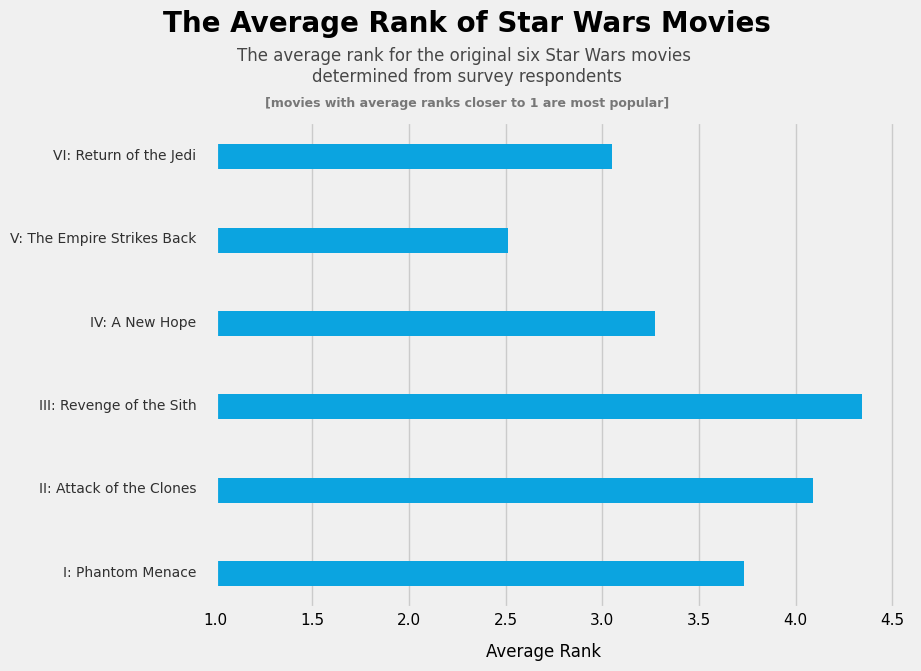

In [19]:
fig, ax = plt.subplots(figsize=(8,6))

ax.barh(y=range(6), width=mean_movie_ranking["mean_rank"], height=0.3, color="#0BA4E0")

plt.yticks([])

y_labels = ["I: Phantom Menace", "II: Attack of the Clones", "III: Revenge of the Sith", "IV: A New Hope", "V: The Empire Strikes Back", "VI: Return of the Jedi"]

j = -0.035

for i in y_labels:
    ax.text(0.9, j, i, fontsize=10, alpha=0.8, ha="right")
    
    j += 1

plt.xlim(1, 4.6)

ax.tick_params(axis='x', labelsize=11)

ax.text(2.3, 6.5, "The Average Rank of Star Wars Movies", fontsize=20, weight='bold', ha="center")
ax.text(2.3, 5.9, "The average rank for the original six Star Wars movies \ndetermined from survey respondents", fontsize=12, ha="center", alpha=0.7)
ax.text(2.3, 5.6, "[movies with average ranks closer to 1 are most popular]", fontsize=9, ha="center", weight='bold', alpha=0.5)

ax.text(2.4, -1, "Average Rank", fontsize=12, color='black')

plt.show()

It appears the original trilogy (episodes IV, V and VI) are viewed more favorably than the three movies that were released later. 

## Most-viewed Star Wars Movie

We can also gain an idea about which movies are viewed the most by determining the percentage of the respondents who have watched each of the six movies. Those with a greater proportion of respondents who have seen the movie would suggest more people in the entire population have likely seen the movie.

In [20]:
movie_viewers = pd.DataFrame(round((star_wars.iloc[:, 3:9].sum() / star_wars["id"].count() *100), 2), columns=["percentage"])

movie_viewers

,percentage
seen_ep_1,56.75
seen_ep_2,48.15
seen_ep_3,46.37
seen_ep_4,51.18
seen_ep_5,63.91
seen_ep_6,62.23


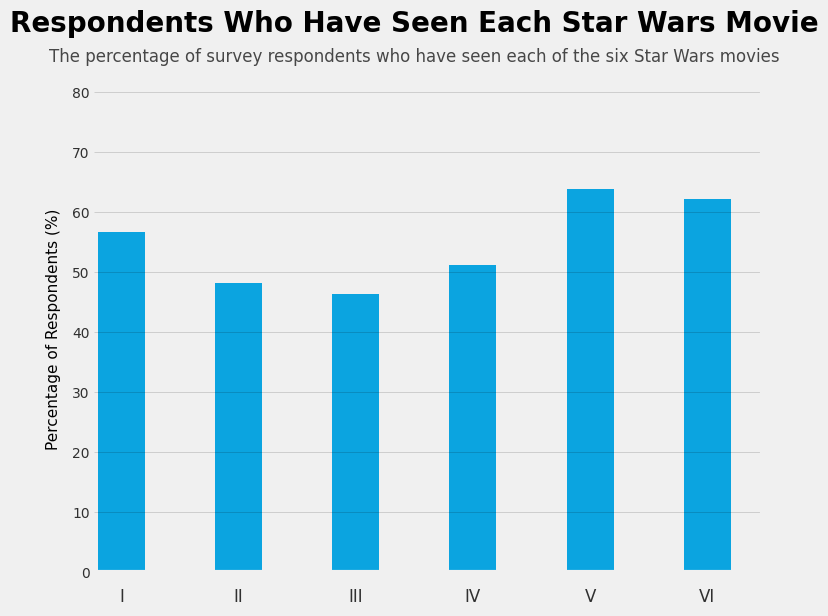

In [21]:
plt.figure(figsize=(8,6))

plt.bar(x=range(6), height=movie_viewers["percentage"], width=0.4, color="#0BA4E0")

plt.xticks([])
plt.yticks([])

x_labels = ["I", "II", "III", "IV", "V", "VI"]

y_labels = [0, 10, 20, 30, 40, 50, 60, 70, 80]

j = 0

for i in x_labels:
    plt.text(j, -5, i, fontsize=12, alpha=0.8, ha="center")
    
    j += 1
    
for i in y_labels:
    plt.text(-0.27, i-1, str(i), fontsize=10, alpha=0.8, ha="right")
    plt.axhline(y=i, xmin=0.04, color='black', linestyle='-', linewidth=0.5, alpha=0.2)

plt.ylim(0, 81)

plt.ylabel("Percentage of Respondents (%)", fontsize=11)

plt.text(2.5, 90, "Respondents Who Have Seen Each Star Wars Movie", fontsize=20, ha="center", weight='bold')
plt.text(2.5, 85, "The percentage of survey respondents who have seen each of the six Star Wars movies", fontsize=12, ha="center", alpha=0.7)

plt.show()

Generally, more respondants reported that they had viewed the original trilogy movies (episodes IV, V and VI) than episodes I, II and III. This falls reinforces the trend observed in the rankings, with the original trilogy appearing more popular. 

## Exploring Ratings and View Count by Binary Segments

Looking deeper into the data, we can split the respondents into two segments (groups), conduct the same analysis as was performed above and compare the trends between the two groups.

### Splitting by Gender

In [22]:
males = star_wars[star_wars["gender"] == "Male"]

females = star_wars[star_wars["gender"] == "Female"]

In [23]:
star_wars["gender"].value_counts(dropna=False)

gender
Female    549
Male      497
NaN       140
Name: count, dtype: int64

There are a relatively even number of males and females in the dataset, though more respondents indicated they were female. Missing values are expected as some respondents will choose not to identify their gender on a survey. These will be omitted from any gender analysis as a result.

In [24]:
male_movie_ranking = pd.DataFrame(males.iloc[:, 9:15].mean(), columns=["male_rank"]) 

female_movie_ranking = pd.DataFrame(females.iloc[:, 9:15].mean(), columns=["female_rank"])

gendered_movie_ranking = pd.concat([male_movie_ranking, female_movie_ranking], axis=1)

gendered_movie_ranking

,male_rank,female_rank
rank_ep_1,4.037825,3.429293
rank_ep_2,4.224586,3.954660
rank_ep_3,4.274882,4.418136
rank_ep_4,2.997636,3.544081
rank_ep_5,2.458629,2.569270
rank_ep_6,3.002364,3.078086


In [25]:
male_movie_viewers = pd.DataFrame(round((males.iloc[:, 3:9].sum() / star_wars["id"].count() *100), 2), columns=["male_percentage"])

female_movie_viewers = pd.DataFrame(round((females.iloc[:, 3:9].sum() / star_wars["id"].count() *100), 2), columns=["female_percentage"])

gendered_movie_viewers = pd.concat([male_movie_viewers, female_movie_viewers], axis=1)

gendered_movie_viewers

,male_percentage,female_percentage
seen_ep_1,30.44,25.13
seen_ep_2,27.23,19.98
seen_ep_3,26.73,18.72
seen_ep_4,28.84,21.50
seen_ep_5,33.05,29.76
seen_ep_6,32.63,28.50


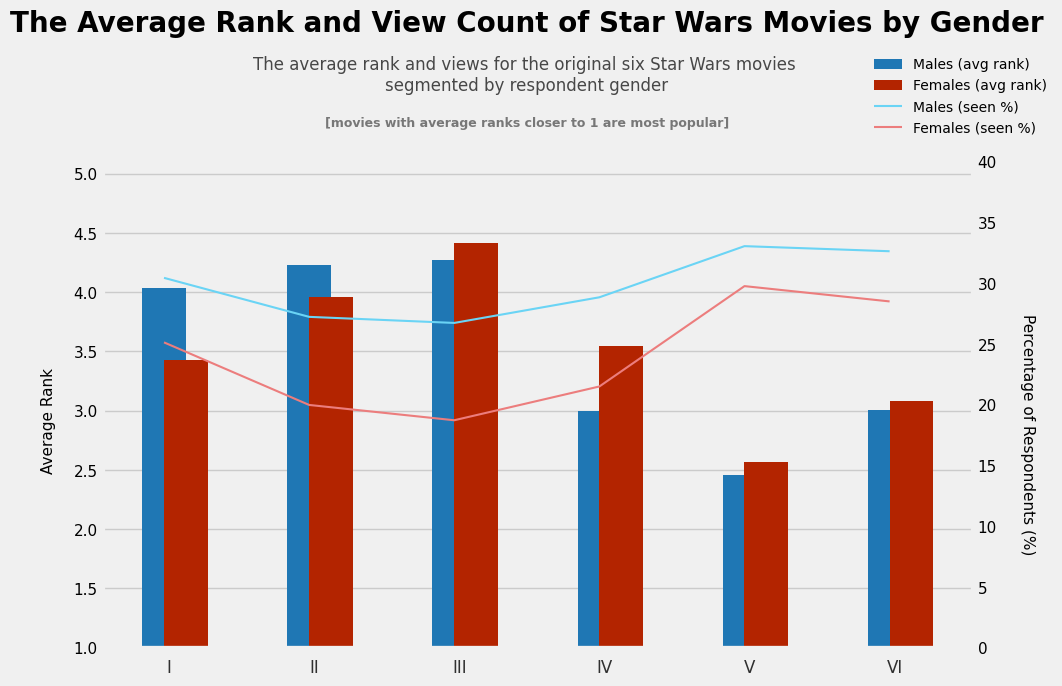

In [26]:
fig, ax = plt.subplots(figsize=(10,6))

ax2 = ax.twinx()

x_labels = ["I", "II", "III", "IV", "V", "VI"]

bar_m = ax.bar(x=range(6), height=gendered_movie_ranking["male_rank"], width=0.3, color="#1f77b4", label="Males (avg rank)")

bar_f = ax.bar(x=range(6), height=gendered_movie_ranking["female_rank"], width=0.3, color="#b32400", label="Females (avg rank)", align="edge")

ax.tick_params(axis='y', labelsize=11)

ax.set_ylim(1, 5.1)

# plot percentages on the secondary y-axis (both genders so legend can show them)
line_m, = ax2.plot(range(6), gendered_movie_viewers["male_percentage"], linewidth=1.5, color="#6ad4f5", label="Males (seen %)")
line_f, = ax2.plot(range(6), gendered_movie_viewers["female_percentage"], linewidth=1.5, color="#ec7d7d", label="Females (seen %)")

# set independent y-limits for the secondary axis
ax2.set_ylim(0, 40)
ax2.tick_params(axis='y', labelsize=11)

ax2.grid(False)

plt.xticks([])

j = 0

for i in x_labels:
    plt.text(j+0.035, -2, i, fontsize=12, alpha=0.8, ha="center") 
    j += 1

ax.text(-0.85, 2.5, "Average Rank", rotation=90, fontsize=11)
ax2.text(5.9, 7.9, "Percentage of Respondents (%)", rotation=270, fontsize=11)

ax.text(2.5, 6.2, "The Average Rank and View Count of Star Wars Movies by Gender", fontsize=20, weight='bold', ha="center")
ax.text(2.5, 5.7, "The average rank and views for the original six Star Wars movies \nsegmented by respondent gender", fontsize=12, ha="center", alpha=0.7)
ax.text(2.5, 5.4, "[movies with average ranks closer to 1 are most popular]", fontsize=9, ha="center", weight='bold', alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

handles = h1 + h2
labels = l1 + l2

ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.1, 1.24), frameon=False, fontsize=10)

plt.show()

### Remarks
#### Average Ranks

Generally, both male and females rank the original six star wars movies in a similar manner, with the original trilogy (IV, V and VI) coming out as the most liked movies. 

Some of the more interesting differences between the two groups:

>* Females typically rated episode I more favorably than males.
>
>* Females tended to rate episode IV **lower** than the male audience. It appears the female audience typically prefers episode I over episode

#### View Count

Turning our attention to the line graphs, we see that a greater proportion of the male survey respondents watched each episode when compared to the group of female respondents. Taking episode I as an example, 30% of the survey respondents who identified as male said they had watched episode I. This is in contrast to the female respondents where only around 25% claimed they had seen episode I. 

Reviewing the trends as a whole, we can identify an interesting point: 

>* Although more males watched episodes I-III than females, males tended to like these movies far less than the female audience.

---
## Comparing Star Wars Fans vs. Non-fans

In [27]:
star_wars_fans = star_wars[star_wars["fan"] == True]

not_star_wars_fans = star_wars[star_wars["fan"] == False]

In [28]:
fan_movie_ranking = pd.DataFrame(star_wars_fans.iloc[:, 9:15].mean(), columns=["fan_rank"]) 

non_fan_movie_ranking = pd.DataFrame(not_star_wars_fans.iloc[:, 9:15].mean(), columns=["non_fan_rank"])

fan_movie_ranking = pd.concat([fan_movie_ranking, non_fan_movie_ranking], axis=1)

fan_movie_ranking

,fan_rank,non_fan_rank
rank_ep_1,4.141304,2.936396
rank_ep_2,4.342391,3.591549
rank_ep_3,4.417423,4.193662
rank_ep_4,2.932971,3.933099
rank_ep_5,2.333333,2.862676
rank_ep_6,2.829710,3.471831


In [29]:
fan_movie_viewers = pd.DataFrame(round((star_wars_fans.iloc[:, 3:9].sum() / star_wars["id"].count() *100), 2), columns=["fan_percentage"])

non_fan_movie_viewers = pd.DataFrame(round((not_star_wars_fans.iloc[:, 3:9].sum() / star_wars["id"].count() *100), 2), columns=["non_fan_percentage"])

fan_movie_viewers = pd.concat([fan_movie_viewers, non_fan_movie_viewers], axis=1)

fan_movie_viewers

,fan_percentage,non_fan_percentage
seen_ep_1,42.16,14.59
seen_ep_2,39.04,9.11
seen_ep_3,37.94,8.43
seen_ep_4,40.73,10.46
seen_ep_5,45.36,18.55
seen_ep_6,45.28,16.95


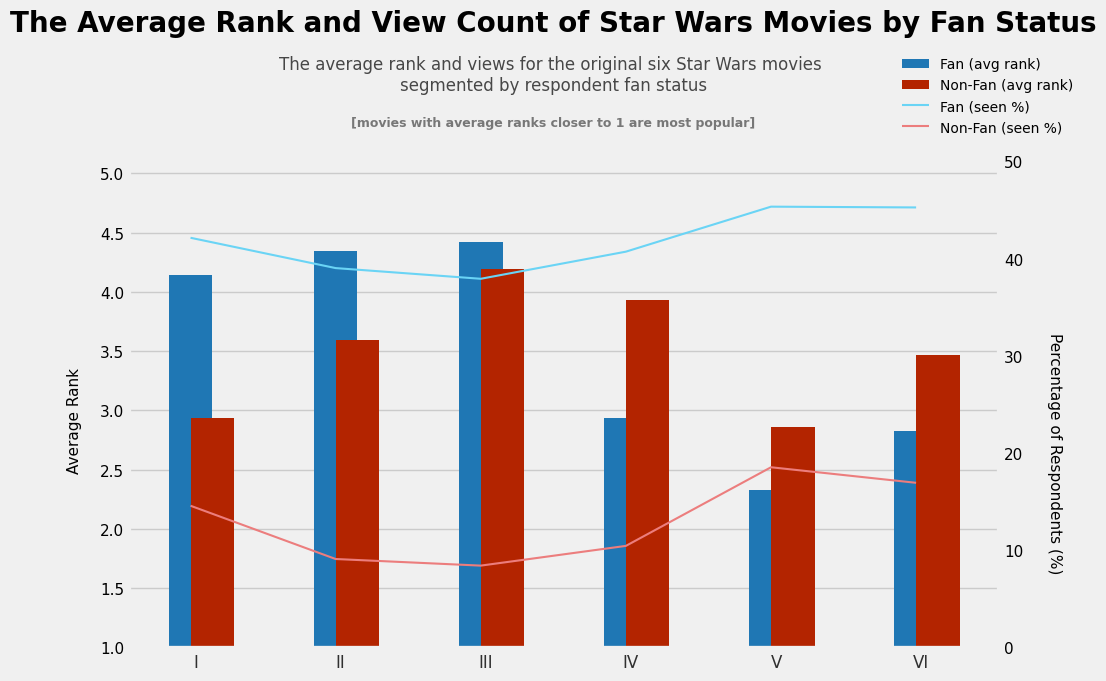

In [30]:
fig, ax = plt.subplots(figsize=(10,6))

ax2 = ax.twinx()

x_labels = ["I", "II", "III", "IV", "V", "VI"]

bar_m = ax.bar(x=range(6), height=fan_movie_ranking["fan_rank"], width=0.3, color="#1f77b4", label="Fan (avg rank)")

bar_f = ax.bar(x=range(6), height=fan_movie_ranking["non_fan_rank"], width=0.3, color="#b32400", label="Non-Fan (avg rank)", align="edge")

ax.tick_params(axis='y', labelsize=11)

ax.set_ylim(1, 5.1)

# plot percentages on the secondary y-axis (both genders so legend can show them)
line_m, = ax2.plot(range(6), fan_movie_viewers["fan_percentage"], linewidth=1.5, color="#6ad4f5", label="Fan (seen %)")
line_f, = ax2.plot(range(6), non_fan_movie_viewers["non_fan_percentage"], linewidth=1.5, color="#ec7d7d", label="Non-Fan (seen %)")

# set independent y-limits for the secondary axis
ax2.set_ylim(0, 50)
ax2.tick_params(axis='y', labelsize=11)

ax2.grid(False)

plt.xticks([])

j = 0

for i in x_labels:
    plt.text(j+0.035, -2, i, fontsize=12, alpha=0.8, ha="center") 
    j += 1

ax.text(-0.85, 2.5, "Average Rank", rotation=90, fontsize=11)
ax2.text(5.9, 7.9, "Percentage of Respondents (%)", rotation=270, fontsize=11)

ax.text(2.5, 6.2, "The Average Rank and View Count of Star Wars Movies by Fan Status", fontsize=20, weight='bold', ha="center")
ax.text(2.5, 5.7, "The average rank and views for the original six Star Wars movies \nsegmented by respondent fan status", fontsize=12, ha="center", alpha=0.7)
ax.text(2.5, 5.4, "[movies with average ranks closer to 1 are most popular]", fontsize=9, ha="center", weight='bold', alpha=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

handles = h1 + h2
labels = l1 + l2

ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.1, 1.24), frameon=False, fontsize=10)

plt.show()

Repeating the analysis, segmenting by respondent self-proclaimed fan-status reveals some interesting patterns:

>* Respondents who claim to be fans have typically viewed a much greater number of the movies (which we would expect) whilst those that do not proclaim themselves as fans typically viewed a considerably smaller number of the movies.
>
>* A clear sentiment is revealed between individuals who proclaim themselves as fans - the newer episodes (I, II and III) are notably ranked lower than the original trilogy. This trend is not exactly reflected in the group that do not identify as fans. Episode I and II in particular are seen more favorably by non-fans.

---

## Character Sentiment Analysis

To gain an insight into which characters are viewed most favorably and which are the least favorite, the fields which asked respondents to rate how much they liked each character can be used. These fields were prepared in the data cleaning section above.

In [ ]:
melt = character_preferences.melt(id_vars='id', var_name='Character', value_name='Sentiment') # transpose the character preferences dataframe

melt = melt.dropna(subset=['Sentiment']) # drop rows with missing values

melt['Character'] = melt['Character'].str.replace(r'^fav_', '', regex=True).str.replace('_', ' ').str.title() # clean character names by removing "fav_", replacing underscores with spaces and capitalizing

melt['Character'] = melt['Character'].replace({"C3Po": "C3PO"}) # replace "C3Po" with "C3PO"

sentiment_counts = (melt                                  # group by character and sentiment, .size() method counts occurrences of Liked/Neutral/Disliked/Unfamiliar
                    .groupby(['Character','Sentiment'])
                    .size()
                    .reset_index(name='Count')
                    .sort_values(['Character','Count'], ascending=[True, False])
                   )

sentiment_counts.reset_index(inplace=True)

sentiment_counts.drop('index', axis=1, inplace=True)

sentiment_counts

,Character,Sentiment,Count
0,Anakin,Liked,514
1,Anakin,Neutral,135
2,Anakin,Disliked,122
3,Anakin,Unfamiliar,52
4,Bobafett,Liked,291
5,Bobafett,Neutral,248
6,Bobafett,Disliked,141
7,Bobafett,Unfamiliar,132
8,C3PO,Liked,703
9,C3PO,Neutral,79


In [ ]:
sentiment_pivot = sentiment_counts.pivot(index='Character', columns='Sentiment', values='Count').fillna(0).astype(int) # pivot the sentiment counts dataframe

sentiment_pivot

Sentiment,Disliked,Liked,Neutral,Unfamiliar
Character,,,,
Anakin,122,514,135,52
Bobafett,141,291,248,132
C3PO,30,703,79,15
Darthvader,251,481,84,10
Hansolo,9,761,44,15
Jarjar,306,242,164,109
Lando,71,365,236,148
Leia,18,757,48,8
Luke,16,771,38,6


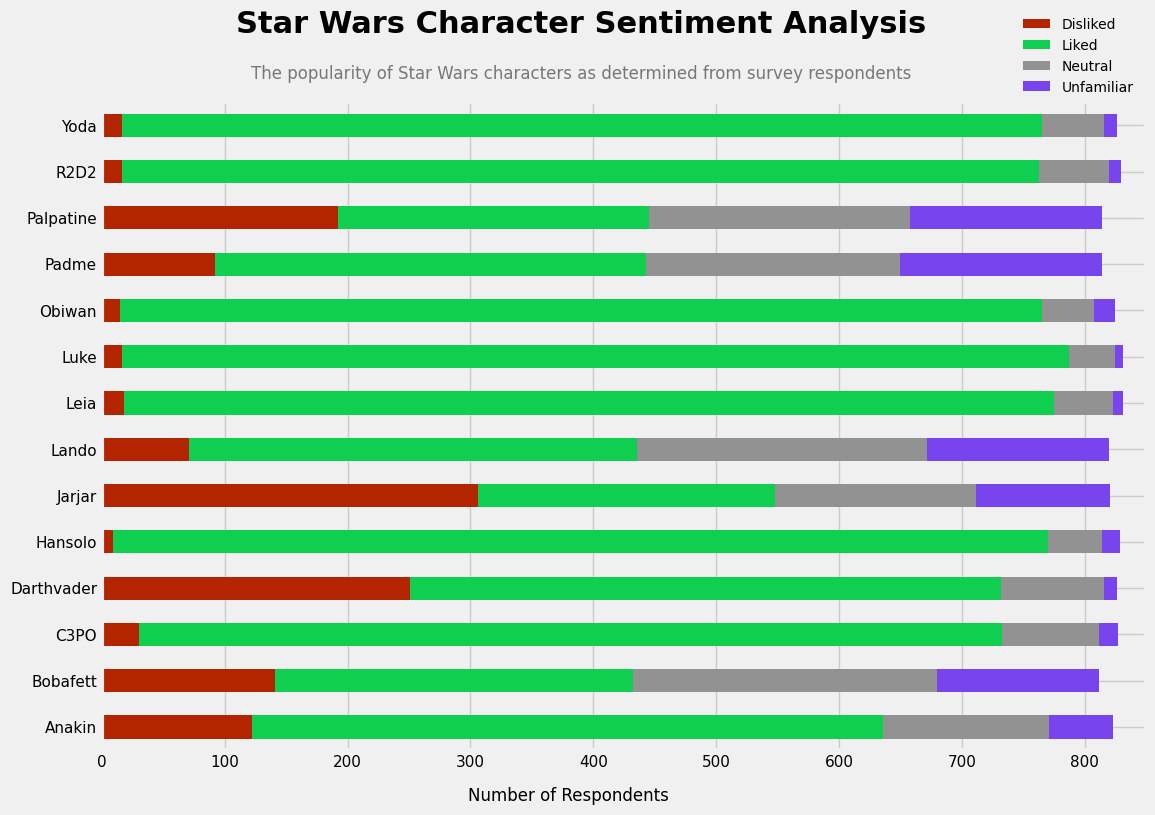

In [50]:
fig, ax = plt.subplots(figsize=(12,8))

sentiment_pivot.plot(kind='barh', stacked=True, width=0.5, color=["#b32400", "#10cf50", "#929292", "#7744EEFF"], ax=ax, legend=False)

ax.set_ylabel("")

ax.tick_params(axis='both', labelsize=11)

ax.text(390, 15, "Star Wars Character Sentiment Analysis", fontsize=22, weight='bold', ha="center")
ax.text(390, 14, "The popularity of Star Wars characters as determined from survey respondents", fontsize=12, ha="center", alpha=0.5)

ax.text(380, -1.6, "Number of Respondents", fontsize=12, ha="center")

ax.set_xlim(0, 850)

plt.legend(bbox_to_anchor=(1, 1.15), frameon=False, fontsize=10)

plt.show()

Typically, the majority of the listed Star Wars characters are liked.

Some interesting observations:

>* Jar-jar Binks is the most devisive character by far, with a roughly even distribution of respondents indicating Like/Dislike/Indifference.
>
>* A number of characters are overwhelmingly liked (Yoda, R2D2, Luke, Leia, Obiwan, Han Solo).
>
>* Generally, the most disliked characters are antagonists or are affiliated with the "Dark-side" (Darth Vader, Emperor Palpatine, Boba Fett) whilst the protagonists (Luke, Obiwan, Leia, ...) who are the stereotypical "good guys" are viewed more favorably.
>
>* A number of characters appear to be more obscure, including: Emperor Palpatine, Lando Calrissian and Padme, among others. This is because more survey respondents indicated they were unfamiliar or left the field blank (presumably because they did not know the character).